In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
#inspect format for the geojson
gdf = gpd.read_file('Current_Police_Districts_20260623.geojson')
gdf.head()

,:id,:version,:created_at,:updated_at,company,district,shape_area,shape_le_1,shape_leng,geometry
0,row-3j9n-8ukt_4ia3,rv-8thz.iwe9.2akg,2023-10-17 19:18:26.068000+00:00,2023-10-17 19:18:26.068000+00:00,B,SOUTHERN,91344142.1925,100231.353916,87550.2751419,"MULTIPOLYGON (((-122.39186 37.79425, -122.3917..."
1,row-c574~56fa_83yj,rv-bnmr_c28d-kte4,2023-10-17 19:18:26.068000+00:00,2023-10-17 19:18:26.068000+00:00,C,BAYVIEW,201384622.317,144143.480351,163013.798332,"MULTIPOLYGON (((-122.38098 37.76480, -122.3810..."
2,row-jart_8zzp.eg62,rv-vmzv.f3ha-8wjq,2023-10-17 19:18:26.068000+00:00,2023-10-17 19:18:26.068000+00:00,D,MISSION,80623839.7922,40518.8342346,40152.783389,"MULTIPOLYGON (((-122.40954 37.76932, -122.4086..."
3,row-9pdz_x6fb~4pkk,rv-749j_gfdi-sz4e,2023-10-17 19:18:26.068000+00:00,2023-10-17 19:18:26.068000+00:00,E,NORTHERN,82781685.5603,50608.3103205,56493.858208,"MULTIPOLYGON (((-122.43379 37.80793, -122.4337..."
4,row-zmma-t2tr.85ju,rv-zn72~rs2u-6x54,2023-10-17 19:18:26.068000+00:00,2023-10-17 19:18:26.068000+00:00,J,TENDERLOIN,11072154.5623,18796.7841847,12424.2689691,"MULTIPOLYGON (((-122.40217 37.78626, -122.4171..."


<Axes: >

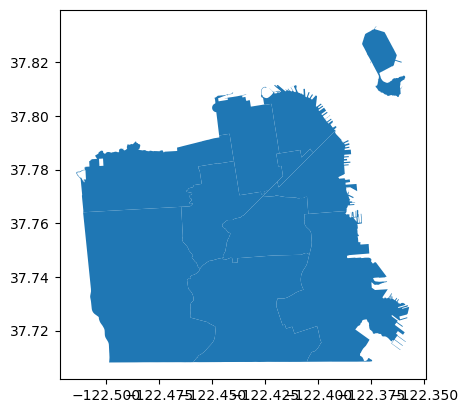

In [ ]:
#make sure it plots! No broken geometries
gdf.plot()

In [4]:
#inspect crs to make sure it's a good one (one we want to work with)
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
#drop columns we don't need, assign new id column
policedistricts = gdf[['district', 'geometry']].copy()
policedistricts['id'] = range(1,11)
policedistricts = policedistricts[['id', 'district', 'geometry']].copy()
policedistricts.head(11)

,id,district,geometry
0,1,SOUTHERN,"MULTIPOLYGON (((-122.39186 37.79425, -122.3917..."
1,2,BAYVIEW,"MULTIPOLYGON (((-122.38098 37.76480, -122.3810..."
2,3,MISSION,"MULTIPOLYGON (((-122.40954 37.76932, -122.4086..."
3,4,NORTHERN,"MULTIPOLYGON (((-122.43379 37.80793, -122.4337..."
4,5,TENDERLOIN,"MULTIPOLYGON (((-122.40217 37.78626, -122.4171..."
5,6,CENTRAL,"MULTIPOLYGON (((-122.42612 37.80684, -122.4261..."
6,7,PARK,"MULTIPOLYGON (((-122.43956 37.78314, -122.4383..."
7,8,RICHMOND,"MULTIPOLYGON (((-122.44127 37.79149, -122.4406..."
8,9,INGLESIDE,"MULTIPOLYGON (((-122.40450 37.74858, -122.4040..."
9,10,TARAVAL,"MULTIPOLYGON (((-122.49842 37.70810, -122.4984..."


In [11]:
#reformat those district names to be normal case
district_names_formatted = ['Southern', 'Bayview', 'Mission', 'Northern', 'Tenerloin',
                            'Central', 'Park', 'Richmond', 'Ingleside', 'Taraval']
policedistricts['name'] = district_names_formatted
policedistricts = policedistricts[['id', 'name', 'geometry']]

<Axes: >

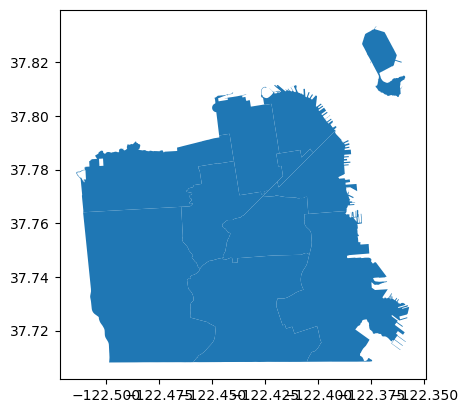

In [12]:
#quick check to make sure we didn't break anything
policedistricts.plot()

In [13]:
#save in a few formats
policedistricts.to_file('sf_police_districts_processed.geojson')
policedistricts.to_csv('sf_police_districts_processed.csv', index=False)